In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
# from tqdm import tqdm
# import gc
# import time
import json
from pprint import pprint
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

import talib

# from pklib.strategy import *
from pklib.utilities import *
# from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *

# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import precision_score, recall_score

# import seaborn as sns
# from pklib.rl import *

### IMPORTANT
# pip install numpy==1.26.4 pandas==2.2.1 --force-reinstall

In [3]:
import dotenv
import os

# Reload the variables in your '.env' file (override the existing variables)
dotenv.load_dotenv(".env", override=True)

# 'MY_VAR' is refreshed now
print('HIP_VISIBLE_DEVICES = ', os.environ.get('HIP_VISIBLE_DEVICES')) # MY_VAR = HELLO_BOB

HIP_VISIBLE_DEVICES =  0


In [4]:

import torch as T
import torch.nn as nn
import torch.optim as optim

In [6]:

# from sklearn.cross_validation import train_test_split
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import precision_score, recall_score

def confusion_matrix_df(y_true, y_pred):
    # Create a 2x2 matrix for binary classification
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    # Create the confusion matrix as a DataFrame
    cm = np.array([[tn, fp], [fn, tp]])
    cm_df = pd.DataFrame(cm, 
                         index=["True Negative", "True Positive"],  # Rows (True Labels)
                         columns=["Predicted Negative", "Predicted Positive"])  # Columns (Predicted Labels)
    
    return cm_df

def precision_recall(cm):
    tn, fp, fn, tp = cm.ravel()  # For binary classification

    # Precision: TP / (TP + FP)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # Recall: TP / (TP + FN)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return precision, recall


def plot_confusion_matrix(cm, labels):
    fig, ax = plt.subplots()
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    # Add labels to the axes
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Rotate the x-axis labels to prevent overlap
    plt.xticks(rotation=45)

    # Annotate the confusion matrix with the numbers
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Example usage
# labels = ['Class 0', 'Class 1'] 

def train_test_split(X, y, test_size=0.25, random_state=None, shuffle=True):
    # Ensure input is a NumPy array
    X = np.array(X)
    y = np.array(y)
    
    # Set the random seed for reproducibility
    if random_state is not None:
        np.random.seed(random_state)
    
    # Shuffle the data
    if shuffle:
        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]
    
    # Compute the split index
    split_idx = int(len(X) * (1 - test_size))
    
    # Split the data into training and testing sets
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    return X_train, X_test, y_train, y_test


import numpy as np
import torch

def create_rolling_windows(data, window_size):
    """
    Create rolling windows of a given size from the input data.
    
    Args:
    - data (np.array): The input data of shape (sequence_length, features)
    - window_size (int): Number of past samples to include at every timestep
    
    Returns:
    - np.array: The data transformed into rolling windows of shape (new_sequence_length, window_size, features)
    """
    rolling_data = []
    
    # Create the windows
    for i in range(len(data) - window_size + 1):
        window = data[i:i + window_size]  # Take a window of 4 samples
        rolling_data.append(window)
    
    return np.array(rolling_data)


In [19]:

device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')
# params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}
# params = {'conversion_periods': 20, 'base_periods': 60, 'lagging_span2_periods': 120, 'displacement': 30}
# Parameters
def load_candles_and_indicators(exchange,asset,quote,timeframe,resample):
    
    df = load_candles(exchange, asset, quote, timeframe).ffill().bfill()
    if resample is not None:
         df = df.resample(resample).agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
    # df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}).ffill().bfill()
    df.drop('volume', axis=1, inplace=True)
    # add_ichimoku_cloud_indicator(df, params={'conversion_periods': 20, 'base_periods': 60, 'lagging_span2_periods': 120, 'displacement': 30})
    # add_ichimoku_cloud_indicator(df, params={'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180})
    # add_bollinger_bands(df, periods=[3,5,7,9,14,21,50,100], multiplier=2)
    # add_rsi_columns(df,periods=[9,14,21])
    # add_adx_columns(df,periods=[9,14,21])
    # add_mom_columns(df,periods=[3,5,7,9,14,21,50,100])
    add_ema_columns(df,periods=[3,5,7,9,7,14,21,50,100])
    add_sma_columns(df,periods=[3,5,7,9,7,14,21,50,100])
    # add_std_columns(df,periods=[3,5,7,9,7,14,21])
    # log_price_over_ma_columns(df,periods=[3,5,9,14,21,50])
    # add_sma_columns(df,periods=[14,21,50,100,200])
    # add_std_columns(df,periods=[14,21,50,100,200])
    # add_donchian_columns(df,periods=[9,14,21,50])
    # add_rolling_max_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
    # add_rolling_min_columns(df,periods=[3,5,7,9,7,14,21,50,100], column="close")
    # add_rolling_max_columns(df,periods=[9,14,21,50], column="high")
    # add_rolling_min_columns(df,periods=[9,14,21,50], column="low")

    # add_shifted_columns(df, periods=[14,21,50,100,200,400], columns=['open','high','low','close'], suffix="_SH")

    df = df.dropna()
    # df = df['2021':]#.iloc[:10000]
    # print(f'DF shape: {df.shape}')
    # df_logprice = df.close.apply(np.log).ffill().bfill()

    # (train_df_features, train_df_log_prices), (test_df_features, test_df_log_prices) = split_dataframes([df, df_logprice], train_size=train_size)

    # add_shifted_columns(df, periods=[1,2,3], columns=['open','high','low','close'], suffix="_SH")
    return df

def prepare_ml_features(df,test_size,window_size=4, lookahead=1, r2rr=2, min_rwd=0.01):
    
    # df = df.dropna()
    dfs = df.apply(np.log)
    # X = df.subtract(df.close, axis=0)
    X = dfs.subtract(dfs.close, axis=0)
    # lookahead = 5
    # Y = (df.low.shift(-1) > df.low).fillna(False).astype(int)
    fwd_min = dfs.low.rolling(lookahead).min().shift(-lookahead)
    fwd_max = dfs.high.rolling(lookahead).max().shift(-lookahead)
    fwd_rwd = (fwd_max - dfs.close)
    fwd_rsk = (dfs.close - fwd_min)
    fwd_rwd_pct = np.expm1(fwd_rwd)
    fwd_rsk_pct = np.expm1(fwd_rsk)

    Y = (fwd_min > dfs.low.rolling(2).min()).fillna(False)
    Y = Y & (fwd_rwd_pct >= r2r*(- fwd_rsk_pct))
    Y = Y & (fwd_rwd_pct >= min_rwd)
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=42, shuffle=False)

    ### Reshape into rolling windows
    X_train_windows = create_rolling_windows(X_train, window_size=window_size)

    # Convert back to a PyTorch tensor
    x_train = torch.tensor(X_train_windows, dtype=torch.float32).to(device)


    # Example: X_train is the input dataframe
    X_test_windows = create_rolling_windows(X_test, window_size=window_size)
    # Convert back to a PyTorch tensor
    x_test = torch.tensor(X_test_windows, dtype=torch.float32).to(device)

    # Example: y_train should have the shape (batch_size, sequence_length, 1), where sequence_length = 4 (window size)
    y_train = torch.tensor(Y_train[window_size-1:], dtype=torch.float32).unsqueeze(1).repeat(1, window_size).unsqueeze(-1).to(device)

    # Similarly, reshape y_test
    y_test = torch.tensor(Y_test[window_size-1:], dtype=torch.float32).unsqueeze(1).repeat(1, window_size).unsqueeze(-1).to(device)
    return x_train, y_train, x_test, y_test


In [8]:

# Define the model class with proper weight initialization
class RollingWindowLSTMBinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(RollingWindowLSTMBinaryClassifier, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer with dropout
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        
        # Fully connected layer to output a single value for binary classification
        self.fc = nn.Linear(hidden_size, 1)
    
        self.to(device)
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                nn.init.zeros_(param.data)
                
        nn.init.xavier_uniform_(self.fc.weight.data)
        nn.init.zeros_(self.fc.bias.data)
    
    def forward(self, x):
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward pass through LSTM
        out, (hn, cn) = self.lstm(x, (h_0, c_0))
        
        # Pass through fully connected layer
        out = self.fc(out)
        
        return out

# Define the evaluation function
def evaluate_model(model, x_data, y_data, dataset_name="Dataset"):
    model.eval()  # Set the model to evaluation mode
    
    with torch.no_grad():  # Disable gradient computation
        # Make predictions
        outputs = model(x_data.to(device))
        predicted = torch.sigmoid(outputs) > 0.5  # Convert logits to binary predictions
        
        # Flatten predictions and ground truth
        predicted_flat = predicted.view(-1).cpu().numpy()
        y_flat = y_data.view(-1).cpu().numpy()
        
        # Compute confusion matrix
        cm = confusion_matrix(y_flat, predicted_flat)
        
        # Compute precision and recall
        precision, recall, _, _ = precision_recall_fscore_support(y_flat, predicted_flat, average='binary')
        
        # Display the confusion matrix
        cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
        print(f"\nConfusion Matrix - {dataset_name}:\n{cm_df}")
        
        # Output precision and recall
        print(f"Precision ({dataset_name}): {precision:.4f}")
        print(f"Recall ({dataset_name}): {recall:.4f}")
        
        return precision, recall

In [9]:

# df

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support



exchange = 'binance'; asset = 'ADA'; quote = 'USDT'; timeframe='1h'; nhours = 8; test_size= 0.5;resample = '10h';
df = load_candles_and_indicators(exchange,asset,quote,timeframe,resample)
lookahead = 1; r2r=3; min_rwd = 0.01;
window_size = 3
x_train, y_train, x_test, y_test = prepare_ml_features(df, test_size=0.5,window_size=window_size,lookahead=lookahead, min_rwd=min_rwd)

# Device configuration
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Parameters
input_size = x_train.size(2)  # Number of features in X_train
hidden_size = input_size * window_size   # Number of hidden units in the LSTM
num_layers = window_size                 # Number of LSTM layers

# Initialize the model
model = RollingWindowLSTMBinaryClassifier(input_size, hidden_size, num_layers, dropout=0.3)

# Calculate class weights
# Y
# y_train = y_train.view(-1)  # Ensure Y_train is 1D
num_neg = (y_train == 0).sum().item()
num_pos = (y_train == 1).sum().item()

if num_pos == 0:
    raise ValueError("No positive samples in Y_train, cannot compute pos_weight.")

pos_weight = torch.tensor([num_neg / num_pos]).to(device)

# Define the loss function with pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer with a lower learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# Optional: Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.80)

# Normalize input data (if not already normalized)
# Example using torch
mean = x_train.mean(dim=(0,1), keepdim=True)
std = x_train.std(dim=(0,1), keepdim=True)
x_train = (x_train - mean) / (std + 1e-8)  # Add epsilon to avoid division by zero

# Training loop
num_epochs = 500
for epoch in range(num_epochs):
    model.train()
    
    # Zero the gradients
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(x_train.to(device))
    
    # Check for NaNs or Infs in outputs
    if torch.isnan(outputs).any() or torch.isinf(outputs).any():
        print(f"Epoch {epoch + 1}: Model outputs contain NaNs or Infs. Stopping training.")
        break
    
    # Compute loss
    loss = criterion(outputs, y_train.to(device))
    
    # Check for NaNs in loss
    if torch.isnan(loss):
        print(f"Epoch {epoch + 1}: Loss is NaN. Stopping training.")
        break
    
    # Backward pass
    loss.backward()
    
    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    # Optimization step
    optimizer.step()
    
    # Scheduler step
    scheduler.step()
    
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Learning Rate: {current_lr:.6f}')

# Evaluate the model after training
evaluate_model(model, x_train, y_train, dataset_name="Train")
evaluate_model(model, x_test, y_test, dataset_name="Test")

Epoch [10/500], Loss: 0.6156, Learning Rate: 0.010000
Epoch [20/500], Loss: 0.6044, Learning Rate: 0.010000
Epoch [30/500], Loss: 0.5947, Learning Rate: 0.010000
Epoch [40/500], Loss: 0.5833, Learning Rate: 0.010000
Epoch [50/500], Loss: 0.5734, Learning Rate: 0.010000
Epoch [60/500], Loss: 0.5557, Learning Rate: 0.010000
Epoch [70/500], Loss: 0.5642, Learning Rate: 0.010000
Epoch [80/500], Loss: 0.5369, Learning Rate: 0.010000
Epoch [90/500], Loss: 0.5172, Learning Rate: 0.010000
Epoch [100/500], Loss: 0.5001, Learning Rate: 0.008000
Epoch [110/500], Loss: 0.4739, Learning Rate: 0.008000
Epoch [120/500], Loss: 0.4587, Learning Rate: 0.008000
Epoch [130/500], Loss: 0.4479, Learning Rate: 0.008000
Epoch [140/500], Loss: 0.4188, Learning Rate: 0.008000
Epoch [150/500], Loss: 0.4088, Learning Rate: 0.008000
Epoch [160/500], Loss: 0.3788, Learning Rate: 0.008000
Epoch [170/500], Loss: 0.3543, Learning Rate: 0.008000
Epoch [180/500], Loss: 0.3869, Learning Rate: 0.008000
Epoch [190/500], Lo

(0.44700082169268696, 0.5688888888888889)

In [128]:
outputs.shape, y_train.shape

(torch.Size([3789, 6, 1]), torch.Size([3791, 6, 1]))

In [29]:


exchange = 'binance'; asset = 'ETH'; quote = 'USDT'; timeframe='1h'; test_size= 1;resample = '11h';
df = load_candles_and_indicators(exchange,asset,quote,timeframe,resample)

x_train, y_train, x_test, y_test = prepare_ml_features(df, test_size=0,window_size=window_size)

# Evaluate on train data
train_precision, train_recall = evaluate_model(model, x_train, y_train, dataset_name="Train")

# Evaluate on test data
# test_precision, test_recall = evaluate_model(model, x_test, y_test, dataset_name="Test")


Confusion Matrix - Train:
          Predicted 0  Predicted 1
Actual 0         3398         4936
Actual 1         3593         4552
Precision (Train): 0.4798
Recall (Train): 0.5589


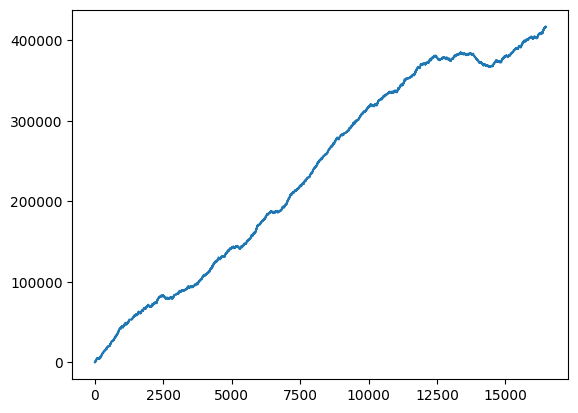

In [50]:
x_data, y_data = x_train, y_train
outputs = model(x_data.to(device))
predicted = torch.sigmoid(outputs) > 0.5  # Convert logits to binary predictions

# Flatten predictions and ground truth
predicted_flat = predicted.view(-1).cpu().numpy()
y_flat = y_data.view(-1).cpu().numpy()

r = (predicted_flat * ( (predicted_flat == y_flat)*3 - 1 ) ) * 100

plt.plot(r.cumsum())



In [46]:
pd.DataFrame(r).value_counts()

0 
 0    6991
-1    4936
 2    4552
Name: count, dtype: int64